In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Task 1. Data Preparation**  

In [7]:
# Load Data customers.csv
customers_csv = pd.read_csv('/content/q2_customers.csv')

In [8]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
nums_cols = customers_csv.select_dtypes(include=np.number).columns
scaler = StandardScaler()

scaled_customers = scaler.fit_transform(customers_csv[nums_cols])

# **Markdown**
**Why scaling is essential before applying K-Means?**

K- Means clustering calculates distance between data point to form clusters. If the features in dataset are on different scale, feature with larger values will dominate the distance calculation.

We use standard scaler to solve this problem by transforming all features to have, mean= 0 and standard deviation= 1, this ensures all features contribute equally to distance calculation and clusters are formed based on true structure rather than scale differences.


# **Task 2. Choosing K — Elbow Method**

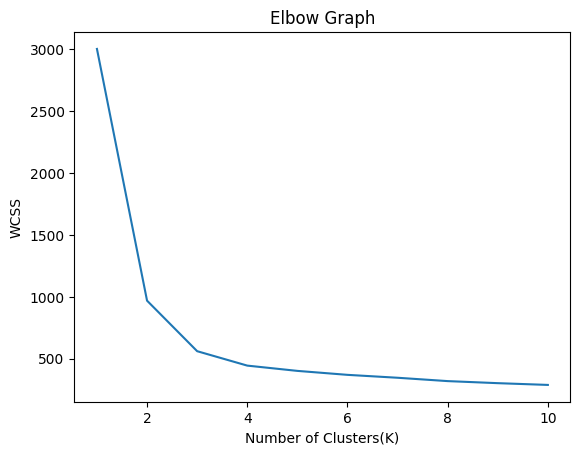

In [9]:
# WCSS
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init= 10)
  kmeans.fit(scaled_customers)
  wcss.append(kmeans.inertia_)

# Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss)
plt.title('Elbow Graph')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('WCSS')
plt.show()

# **Markdown**
The Elbow Method helps determine the optimal number of clusters by plotting, Within-Cluster Sum of Squares against different values of K.

WCSS decreases as the K increases because cluster become more compact.

As per the graph there is decrease in WCSS from K=1 to K=3, after that the reduction in WCSS becomes much smaller and the curve starts to flatten.

This indicates adding more clusters beyond K=3 does not significantly improve performance.

Therefore the optimal number of clusters is K=3, as it indicates elbow point.


# **Task 3. K-Means Clustering**


In [10]:

K = 4

# Fit KMeans
kmeans = KMeans(n_clusters=K, random_state=42, n_init= 10)
clusters = kmeans.fit_predict(scaled_customers)

# Adding Cluster Column
customers_csv['cluster'] = clusters

# Cluster Column Centroid
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=nums_cols)
centroids


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.150795,1.247783,-1.118857,1.150217,1.984595,1.161639
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968
3,1.114725,1.224083,-1.095219,1.350241,0.317376,1.183676


# **Markdown**
**K-Means clustering Interpretation (K=4)**



1.   Cluster 0- This group represent customers with moderate value across most features.
2.   Cluster 1- Customers in this cluster shows higher value for key features.
3.   Cluster 2- This cluster indicates lower value for key features, customers indicates low spending or low enagaged.
4.   Cluster 3- This group shows distinct behaviour compared to others.



# **Task 4. Dimensionality Reduction with PCA**

In [11]:
from sklearn.decomposition import PCA

# PCA to reduce the data to 2 principal components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_customers)

# Variance Ratio
print(pca.explained_variance_ratio_)

[0.83560354 0.05568764]


In [12]:
# Feature Loadings (Components)
loading = pd.DataFrame(pca.components_, columns=nums_cols, index=['PC1', 'PC2'])
loading


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


# **Markdown**
PCA Interpretations


1.   PC1- PC1 has strong positive loadings on age, annual_spend, basket_size, days_since_last_visit, and num_categories_purchased, and a negative loading on visits_per_month. Customer with high PC1 scores tends to spend more, larger basket size, purchase across more categories and visit less frequently.
2.   PC2- PC2 is dominated by a very stong positive loading on days_since_last_visit with less contribution from others. This indicates PC2 have high inactive customers.



# **Task 5. Cluster Visualisation**

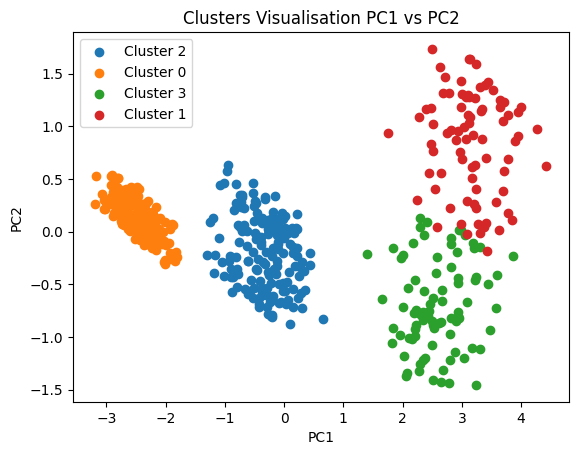

In [13]:
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = customers_csv['cluster']

# Scatter Plot
plt.figure()
for cluster in customers_csv['cluster'].unique():
  subset = pca_df[pca_df['Cluster'] == cluster]
  plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters Visualisation PC1 vs PC2')
plt.legend()
plt.show()